### Import Libraries and Load Dataset



In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# Load the dataset
#df = pd.read_csv("https://raw.githubusercontent.com/ThirafiQaedi/proyek-machile-learning-terapan-1-dicoding/refs/heads/main/Student%20Depression%20Dataset.csv?token=GHSAT0AAAAAADDMPIOWF42AAP3YDUW3SM7C2COUGBQ")

df = pd.read_csv("/content/Student Depression Dataset.csv")
print("Data Preview:")
df

Data Preview:


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


Insight :
- dataset diload dari data yang sudah disimpan di [Repositori github](https://github.com/ThirafiQaedi/proyek-machile-learning-terapan-1-dicoding/tree/main)
- Sumber Dataset kaggle: [Student Depression Dataset.](https://www.kaggle.com/datasets/hopesb/student-depression-dataset)
- terdapat 27901  baris data dalam dataset
- terdapat 18 kolom data yaitu : id, Gender, Age, City, Profession, Academic Pressure, Work Pressure, CGPA, Study Satisfaction, Job Satisfaction, Sleep Duration, Dietary Habits, Degree, Have you ever had suicidal thoughts ?,Work/Study Hours ,Financial Stress ,Family History of Mental Illness, Depression.





### Exploratory Data Analysis (EDA)


#### deskripsi variable

##### deskripsi variable umum

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [28]:
# memisahkan kolom tipe numerik dan kategori
pre_numerical_features = df.select_dtypes(include='number').columns
pre_categorical_features = df.select_dtypes(include='object').columns

# print kolom numerik
print('kolom numerik : ')
for col in pre_numerical_features:
  print(f"-{col}")

# print kolom kategori
print('\nkolom kategori : ')
for col in pre_categorical_features:
  print(f"-{col}")

kolom numerik : 
-id
-Age
-Academic Pressure
-Work Pressure
-CGPA
-Study Satisfaction
-Job Satisfaction
-Work/Study Hours
-Financial Stress
-Depression

kolom kategori : 
-Gender
-City
-Profession
-Sleep Duration
-Dietary Habits
-Degree
-Have you ever had suicidal thoughts ?
-Family History of Mental Illness


Insight:
- terdapat 10 kolom numerik dan 8 kolom kategorickal
- terdapat 8 kolom kategorikal dengan tipe data object yaitu kolom Gender, City, Profession, Sleep Duration, Dietary Habits, Degree, Have you ever had suicidal thoughts ?, Family History of Mental Illness
- terdapat 8 kolom numerik dengan tipe data float64 yaitu kolom Age, Academic Pressure, Work Pressure, CGPA, Study Satisfaction, Job Satisfaction, Work/Study Hours, Financial Stress
- terdapat 2 kolom numerik dengan tipe data int64, yaitu: Depression, id

##### check missing value dan duplikat

In [29]:
print("\nMissing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [30]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah data duplikat: {jumlah_duplikat}")

Jumlah data duplikat: 0


insight:
- tidak ada data duplikat
- terdapat 3 missing value di kolom Financial Stress

##### statistic umum data numeric

In [31]:
print("\nRingkasan Statistik untuk Fitur Numerik:")
print(df.describe())


Ringkasan Statistik untuk Fitur Numerik:
                  id           Age  Academic Pressure  Work Pressure  \
count   27901.000000  27901.000000       27901.000000   27901.000000   
mean    70442.149421     25.822300           3.141214       0.000430   
std     40641.175216      4.905687           1.381465       0.043992   
min         2.000000     18.000000           0.000000       0.000000   
25%     35039.000000     21.000000           2.000000       0.000000   
50%     70684.000000     25.000000           3.000000       0.000000   
75%    105818.000000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27901.000000        27901.000000      27901.000000      27901.000000   
mean       7.656104            2.943837          0.000681          7.156984   
std        1.470707            1.361148          0.044394          3.707

#### Distribusi data

##### Univariate Analysis pada kolom di fitur categorical

In [32]:
for col in pre_categorical_features:
    unique_count = df[col].nunique()
    print(f"\nJumlah kelas unik di kolom '{col}': {unique_count}")
    print(f"Jumlah data per kelas pada kolom '{col}':")
    print(df[col].value_counts())


Jumlah kelas unik di kolom 'Gender': 2
Jumlah data per kelas pada kolom 'Gender':
Gender
Male      15547
Female    12354
Name: count, dtype: int64

Jumlah kelas unik di kolom 'City': 52
Jumlah data per kelas pada kolom 'City':
City
Kalyan                1570
Srinagar              1372
Hyderabad             1340
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1066
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               685
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik     

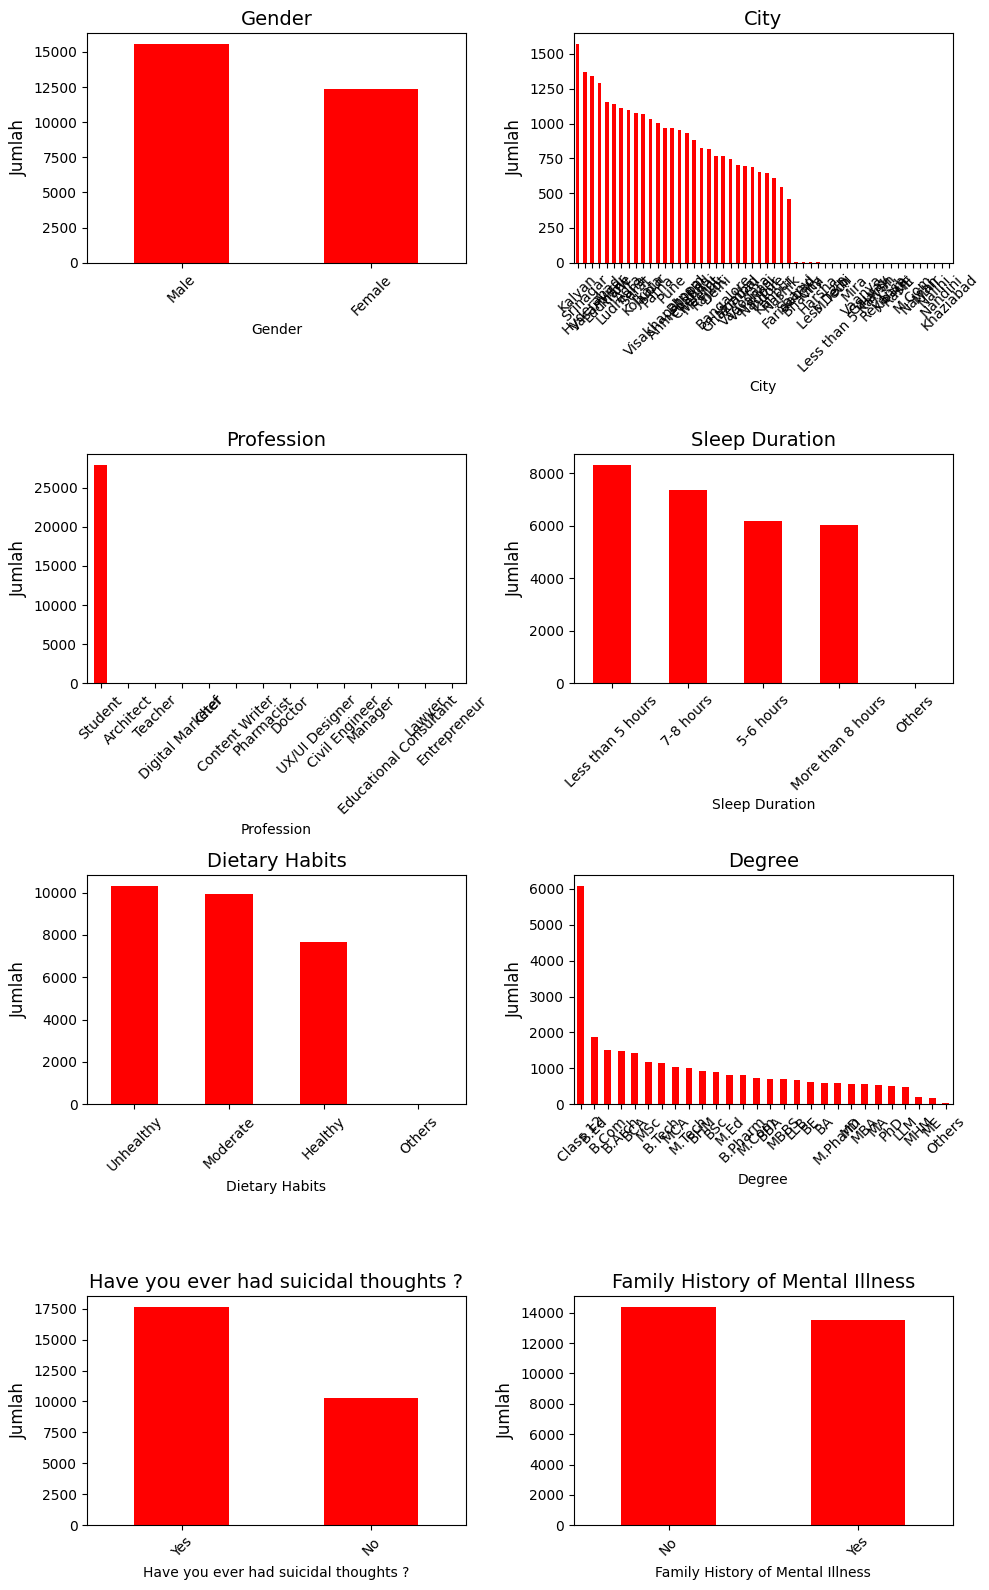

In [33]:
n_features = len(pre_categorical_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(pre_categorical_features):
    count = df[col].value_counts()
    count.plot(kind='bar', color='red', ax=axes[i])
    axes[i].set_title(col, fontsize=14)
    axes[i].set_ylabel("Jumlah", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45, labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

insight:
- Terdapat 2 kategori dalam fitur **Gender**, didominasi oleh **Male** (15 547) dan **Female** (12 354) dengan perbandingan sekitar 55% vs 45%.  
- Terdapat 52 kategori dalam fitur **City**, dengan tiga kota terbanyak: **Kalyan** (1 570), **Srinagar** (1 372), dan **Hyderabad** (1 340); puluhan entri hanya muncul sekali sehingga sebaiknya digabung ke “Others”.  
- Terdapat 14 kategori dalam fitur **Profession**, sangat didominasi oleh **Student** (27 870), sedangkan kategori lain jumlahnya sangat kecil (<10).  
- Terdapat 5 kategori dalam fitur **Sleep Duration**, secara berurutan: **Less than 5 hours** (8 310), **7–8 hours** (7 346), **5–6 hours** (6 183), **More than 8 hours** (6 044), dan **Others** (18).  
- Terdapat 4 kategori dalam fitur **Dietary Habits**, secara berurutan: **Unhealthy** (10 317), **Moderate** (9 921), **Healthy** (7 651), dan **Others** (12).  
- Terdapat 28 kategori dalam fitur **Degree**, dengan paling banyak **Class 12** (6 080), diikuti **B.Ed** (1 867) dan **B.Com** (1 506); banyak kategori jarang (<200) yang sebaiknya dikelompokkan.  
- Terdapat 2 kategori dalam fitur **Have you ever had suicidal thoughts?**, yaitu **Yes** (17 656) dan **No** (10 245), dengan ~63% responden pernah berpikir bunuh diri.  
- Terdapat 2 kategori dalam fitur **Family History of Mental Illness**, yaitu **No** (14 398) dan **Yes** (13 503), dengan proporsi relatif cukup seimbang yiatu (52% vs 48%).  

#####Univariate Analysis pada kolom di fitur numerical

In [34]:
for col in pre_numerical_features:
    unique_count = df[col].nunique()
    print(f"\nJumlah kelas unik di kolom '{col}': {unique_count}")
    print(f"Jumlah data per kelas pada kolom '{col}':")
    print(df[col].value_counts())


Jumlah kelas unik di kolom 'id': 27901
Jumlah data per kelas pada kolom 'id':
id
140699    1
2         1
8         1
26        1
30        1
         ..
132       1
120       1
106       1
103       1
100       1
Name: count, Length: 27901, dtype: int64

Jumlah kelas unik di kolom 'Age': 34
Jumlah data per kelas pada kolom 'Age':
Age
24.0    2258
20.0    2237
28.0    2133
29.0    1950
33.0    1893
25.0    1784
21.0    1726
23.0    1645
18.0    1587
19.0    1560
34.0    1468
27.0    1462
31.0    1427
32.0    1262
22.0    1160
26.0    1155
30.0    1145
35.0      10
38.0       8
36.0       7
42.0       4
39.0       3
48.0       3
46.0       2
43.0       2
37.0       2
44.0       1
51.0       1
49.0       1
58.0       1
54.0       1
59.0       1
56.0       1
41.0       1
Name: count, dtype: int64

Jumlah kelas unik di kolom 'Academic Pressure': 6
Jumlah data per kelas pada kolom 'Academic Pressure':
Academic Pressure
3.0    7462
5.0    6296
4.0    5155
1.0    4801
2.0    4178
0.0       9


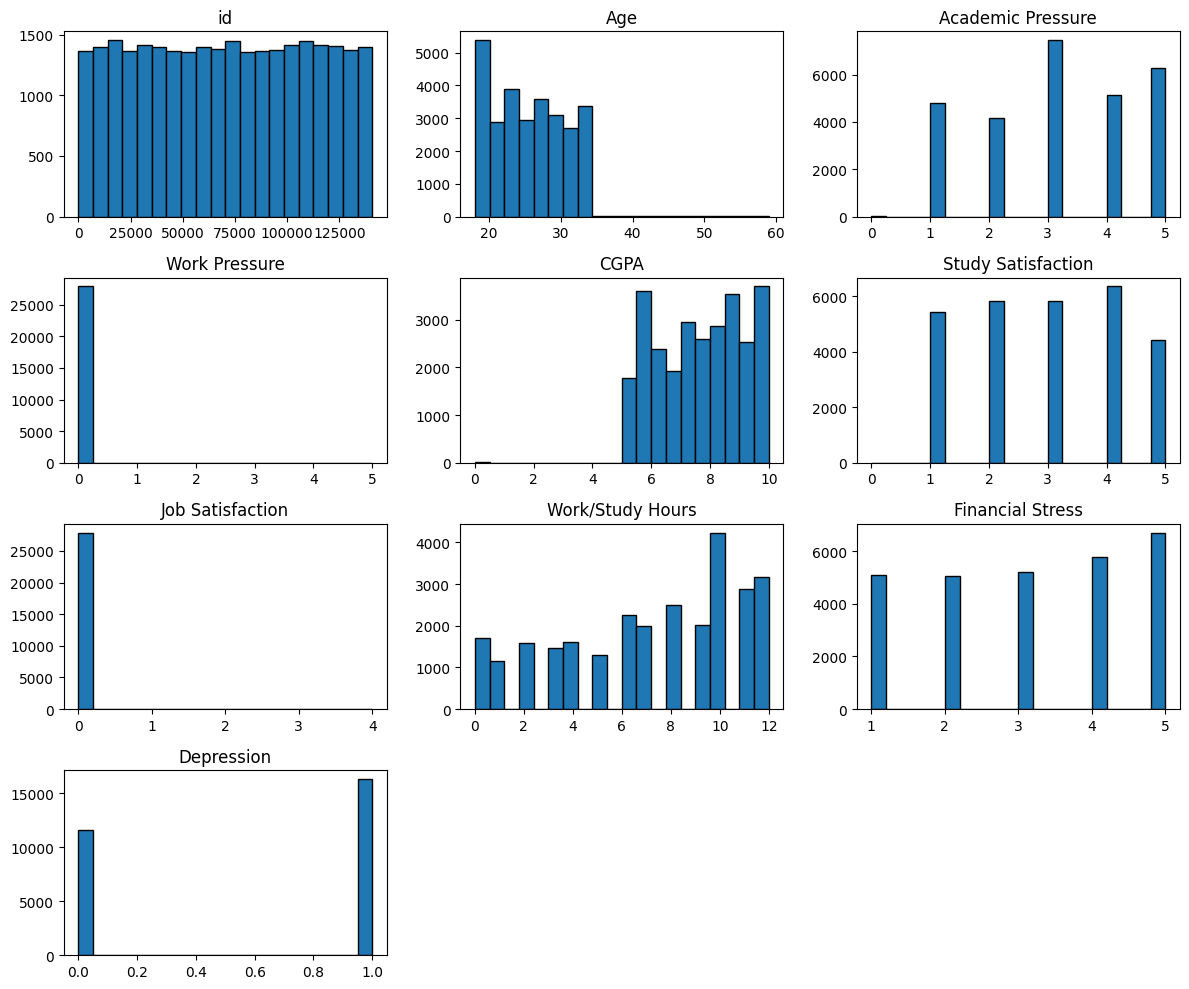

In [35]:

plt.figure(figsize=(12, 10))
for i, col in enumerate(pre_numerical_features):
    plt.subplot(4, 3, i+1)
    plt.hist(df[col].dropna(), bins=20, edgecolor='black')
    plt.title(col)
plt.tight_layout()
plt.show()

insight:
- **id**: Terdiri dari 27 901 nilai unik (satu per baris), menandakan kolom ini hanya sebagai identifier dan tidak berkontribusi ke pola data.  
- **Age**: Terdapat 34 nilai usia berbeda; puncak pada usia 24 (2 258), 20 (2 237), dan 28 (2 133). Sebagian besar responden berusia 18–34 tahun, dengan sedikit outlier (>35 tahun).  
- **Academic Pressure**: 6 kategori (0–5), didominasi nilai 3 (7 462), 5 (6 296), 4 (5 155), 1 (4 801), dan 2 (4 178). Hanya 9 responden melaporkan nol tekanan.  
- **Work Pressure**: 3 kategori, hampir seluruhnya 0 (27 898), hanya 3 responden melaporkan tekanan kerja >0. Fitur ini hampir konstan dan perlu dipertimbangkan ulang.  
- **CGPA**: 332 nilai unik, berkisar 0–10; mayoritas di rentang 5–10 dengan puncak pada 8,04 (821) dan 9,96 (425). Menunjukkan kinerja akademik umumnya tinggi.  
- **Study Satisfaction**: 6 kategori (0–5), didominasi nilai 4 (6 359), 2 (5 838), 3 (5 821), 1 (5 451), 5 (4 422). Hanya 10 responden sangat tidak puas (0).  
- **Job Satisfaction**: 5 kategori, hampir semua 0 (27 893), sisanya tersebar sangat jarang (1–4). Mirip dengan Work Pressure, fitur ini kurang informatif.  
- **Work/Study Hours**: 13 nilai (0–12 jam), puncak pada 10 jam (4 234), 12 jam (3 172), dan 11 jam (2 892). Menunjukkan sebagian besar menghabiskan 8–12 jam per hari.  
- **Financial Stress**: 5 kategori (1–5), didominasi nilai 5 (6 715) dan 4 (5 775), artinya tekanan finansial cenderung tinggi pada responden.  
- **Depression (target)**: Dua kelas, dengan 16 336 (≈58,5 %) positif depresi dan 11 565 (≈41,5 %) negatif. Menunjukkan ketidakseimbangan yang perlu diperhatikan dalam pemodelan (misal: resampling).  

Correation Matrix

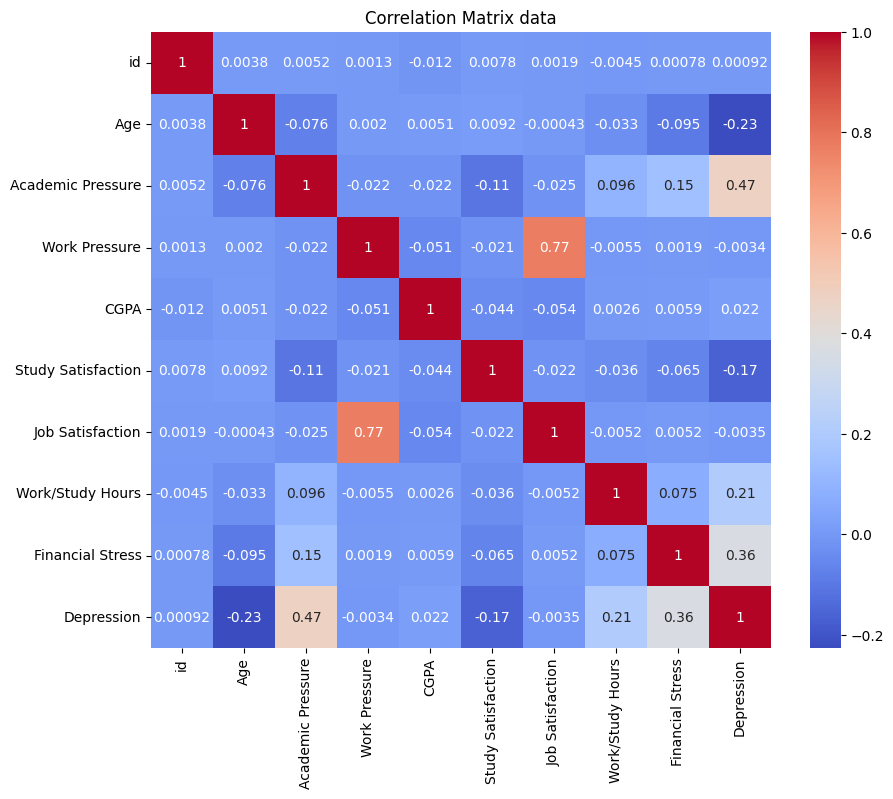

In [36]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
corr_pre = df[pre_numerical_features].corr()
sns.heatmap(corr_pre, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix data')
plt.show()

insight :
- **Academic Pressure** menunjukkan korelasi positif tertinggi dengan **Depression** (0.47), artinya semakin tinggi tekanan akademik, semakin besar kemungkinan gejala depresi.  
- **Financial Stress** juga berkorelasi positif sedang dengan **Depression** (0.36), menandakan bahwa beban finansial menjadi faktor risiko kedua setelah tekanan akademik.  
- **Work/Study Hours** memiliki korelasi positif moderat dengan **Depression** (0.21), yang bisa diartikan bahwa jam belajar/kerja yang panjang berhubungan dengan peningkatan risiko depresi.  
- **Age** berkorelasi negatif dengan **Depression** (–0.23), menunjukkan bahwa peserta yang lebih muda cenderung melaporkan tingkat depresi lebih tinggi.  
- **Study Satisfaction** memiliki korelasi negatif kecil dengan **Depression** (–0.17), menandakan bahwa kepuasan studi sedikit menurunkan risiko depresi.  
- **CGPA**, **Work Pressure**, dan **Job Satisfaction** hampir tidak berkorelasi dengan **Depression** (< 0.03), sehingga kontribusinya dalam prediksi depresi diperkirakan minimal.  
- **Work Pressure** dan **Job Satisfaction** sangat berkorelasi satu sama lain (0.77), menandakan kemungkinan duplikasi informasi—sebaiknya hanya salah satu yang dipakai.  
- Kolom **id** tidak berkorelasi signifikan dengan fitur apapun (< 0.01), sehingga bisa dihapus sebagai identifier tanpa kehilangan informasi.  

##### melakukan pengecekan outliner

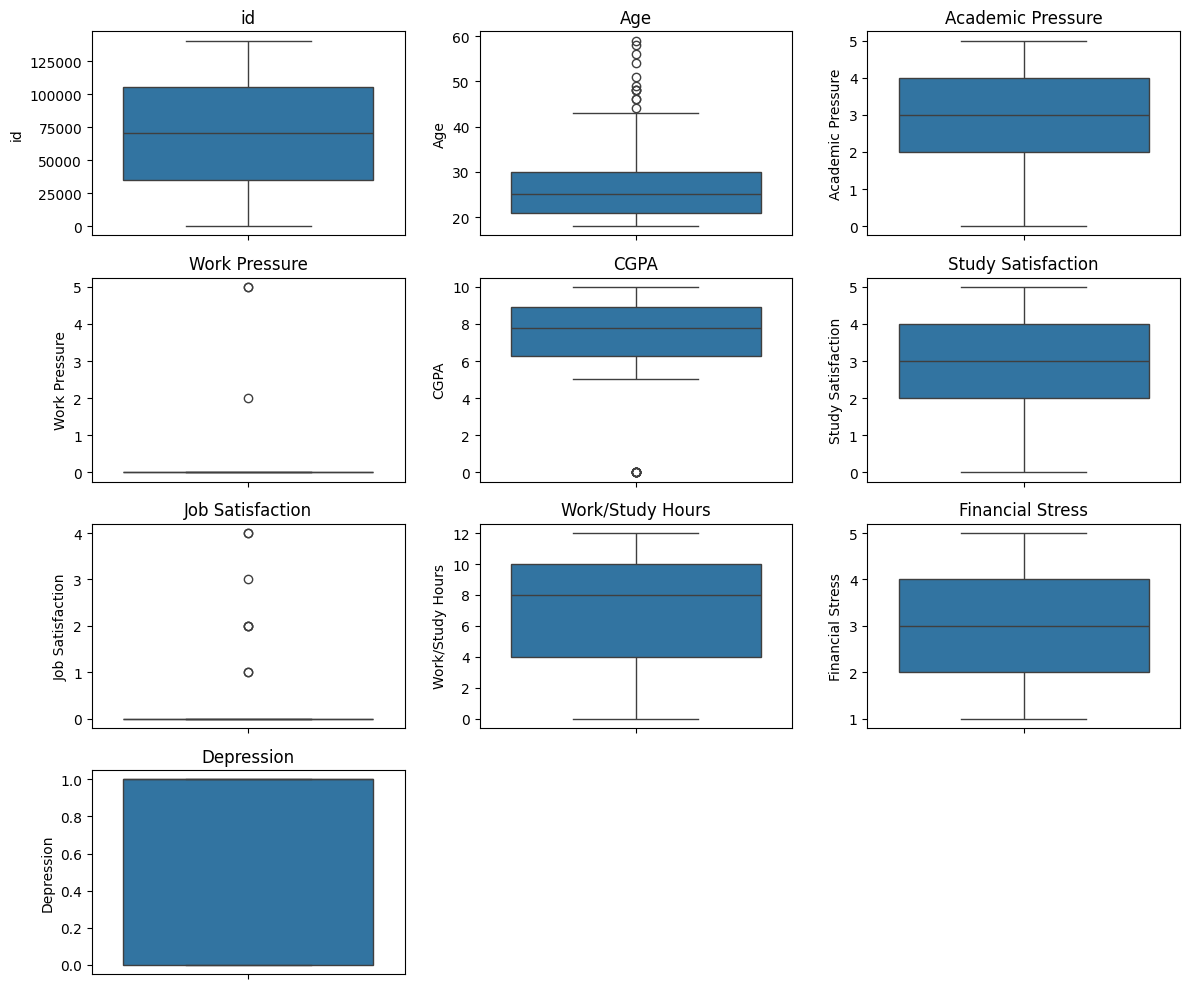

In [37]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(pre_numerical_features):
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

insight:

- **Age**  
  - Sebagian besar usia terpusat pada 18–34 tahun (IQR ≈ 21–30).  
  - Terdapat outlier usia >35 tahun (hingga ≈ 59), perlu dicek apakah ini partisipan lanjut usia atau kesalahan input.

- **Academic Pressure**  
  - Distribusi terpusat pada 2–4, tanpa outlier signifikan di luar rentang 0–5.

- **Work Pressure**  
  - Hampir semua nilai 0, kecuali tiga responden (skor 2 dan 5) yang muncul sebagai outlier—menunjukkan mayoritas tidak memiliki beban kerja sampingan.

- **CGPA**  
  - Sebagian besar di rentang 5–10, tetapi ada satu nilai 0 yang jelas outlier (tidak valid) dan perlu diperbaiki atau dihapus.

- **Study Satisfaction**  
  - Sebagian besar skor 1–5, dengan beberapa very-low score (0) muncul sebagai outlier. Perlu verifikasi apakah 0 tersebut missing value tersembunyi.

- **Job Satisfaction**  
  - Didominasi nilai 0, sedangkan nilai 1–4 hanya beberapa sampel saja—kategori yang muncul sebagai outliner

##### Multivariate Analysis

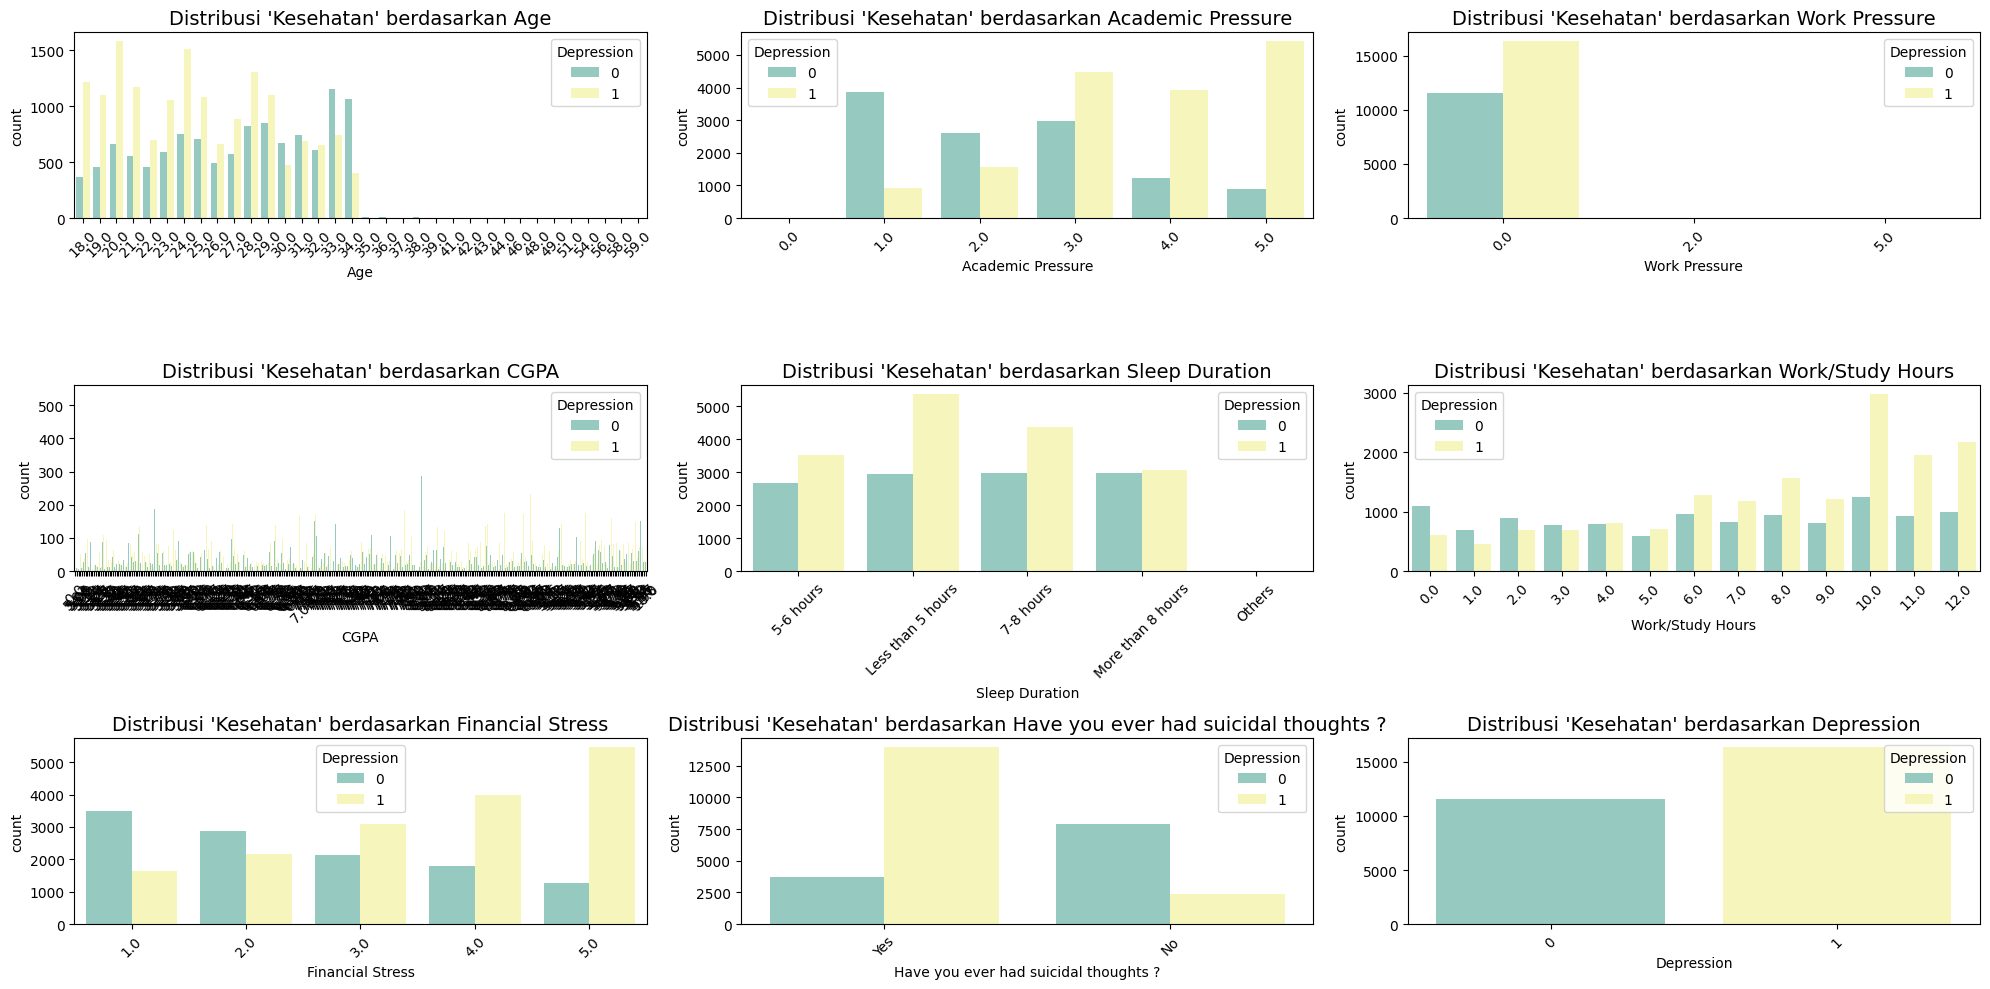

In [38]:
cat_features = ['Age','Academic Pressure', 'Work Pressure' ,'CGPA', 'Sleep Duration', 'Work/Study Hours', 'Financial Stress','Have you ever had suicidal thoughts ?','Depression']

n_features = len(cat_features)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='Depression', data=df, palette='Set3', ax=axes[i])
    axes[i].set_title(f"Distribusi 'Kesehatan' berdasarkan {col}", fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

insight:
- **Age**  
  Meskipun jumlah total responden tertinggi ada di rentang 20–30 tahun (khususnya 24 dan 28 tahun), hampir di semua kategori umur jumlah kasus depresi (bar kuning) selalu melebihi non-depresi (bar hijau).  

- **Academic Pressure**  
  Semakin tinggi tekanan akademik, proporsi depresi juga meningkat:  
  - AP=5 dan 4 didominasi kasus depresi  
  - AP=3 relatif seimbang  
  - AP=1–2 lebih banyak non-depresi  

- **Work Pressure**  
  Hampir semua responden melaporkan WP=0, sehingga fitur ini tidak membedakan kasus depresi.  

- **CGPA**  
  Kasus depresi dan non-depresi tersebar merata di seluruh rentang CGPA, menandakan CGPA bukan prediktor kuat.  

- **Sleep Duration**  
  - Tidur <5 jam dan 5–6 jam → proporsi depresi lebih tinggi  
  - Tidur 7–8 jam dan >8 jam → lebih seimbang atau sedikit didominasi non-depresi  

- **Work/Study Hours**  
  Beban jam belajar/kerja tinggi (10–12 jam) berhubungan dengan peningkatan proporsi depresi, sedangkan jam rendah (0–4 jam) cenderung lebih banyak non-depresi.  

- **Financial Stress**  
  Tekanan finansial tinggi (skor 4–5) didominasi responden depresi, sedangkan skor rendah (1–2) lebih banyak non-depresi.  

- **Suicidal Thoughts**  
  Hampir seluruh yang pernah berpikir bunuh diri (Yes) juga berstatus depresi, sedangkan yang tidak (No) sebagian besar non-depresi.  

- **Target Imbalance**  
  Label `Depression` menunjukkan ~16 300 positif vs ~11 500 negatif, perlu penanganan imbalance (misal resampling atau threshold tuning) pada tahap pemodelan.


### Data Preprocessing dan Cleaning  


In [39]:
print("\nDataset Info sebelum Cleaning:")
df.info()
print("\n\nData Preview sebelum Cleaning:")
df.head()


Dataset Info sebelum Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                        

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [40]:
# Menghapus missing value
df = df.dropna()

insight:
-  mengahpus missing value

In [41]:
# Konversi kolom yang sesuai ke tipe 'category'
df['Gender'] = df['Gender'].astype('category')
df['City'] = df['City'].astype('category')

# Ganti nama kolom untuk pikiran bunuh diri dan riwayat penyakit mental menjadi nama sederhana dan konversi dengan mapping
df.rename(columns={'Have you ever had suicidal thoughts ?': 'Suicidal_Thoughts'}, inplace=True)
df['Suicidal_Thoughts'] = df['Suicidal_Thoughts'].map({'Yes': 1, 'No': 0})


df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map({'Yes': 1, 'No': 0})


df['Sleep Duration'] = df['Sleep Duration'].str.replace('"', '', regex=False)\
                                      .str.strip("'").str.strip()

# Debug: Print distinct cleaned values in Sleep Duration
print("\nDNilai unik pada kolom 'Sleep Duration' setelah cleaning:")
print(df['Sleep Duration'].unique())

# Konversi deskripsi durasi tidur teks ke nilai numerik menggunakan mapping
sleep_mapping = {
    'Less than 5 hours': 4.0,
    '5-6 hours': 5.5,
    '7-8 hours': 7.5,
    'More than 8 hours': 9.0
}
df['Sleep_Duration_Num'] = df['Sleep Duration'].replace(sleep_mapping)

# Untuk entri yang masih 'Others', ubah menjadi NaN
df['Sleep_Duration_Num'] = df['Sleep_Duration_Num'].replace("Others", np.nan)

# Isi nilai durasi tidur yang hilang (dari 'Others' atau masalah mapping) dengan median
median_sleep = df['Sleep_Duration_Num'].median()
df['Sleep_Duration_Num'] = df['Sleep_Duration_Num'].fillna(median_sleep)

# Konversi eksplisit Sleep_Duration_Num ke float
df['Sleep_Duration_Num'] = df['Sleep_Duration_Num'].astype(float)

# Konversi kolom numerik lainnya ke tipe numerik yang tepat
numeric_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
                'Financial Stress', 'Depression']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# memastikan juga 'Family History of Mental Illness' bertipe numerik
df['Family History of Mental Illness'] = pd.to_numeric(df['Family History of Mental Illness'], errors='coerce')




DNilai unik pada kolom 'Sleep Duration' setelah cleaning:
['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours' 'Others']


<ipython-input-41-914411390>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].astype('category')
<ipython-input-41-914411390>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['City'] = df['City'].astype('category')
<ipython-input-41-914411390>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d

insight:
- Mengonversi **Gender** dan **City** ke tipe `category` untuk menghemat memori dan memudahkan encoding fitur kategorikal.  
- Menyederhanakan nama kolom `Have you ever had suicidal thoughts ?` menjadi `Suicidal_Thoughts` dan mengubah nilainya menjadi **1** (Yes) dan **0** (No), serta `Family History of Mental Illness` juga menjadi **1** atau **0**.  
- Membersihkan kolom **Sleep Duration** dengan menghapus tanda kutip dan spasi ekstra, sehingga menghasilkan lima nilai bersih:  
  - `Less than 5 hours`  
  - `5-6 hours`  
  - `7-8 hours`  
  - `More than 8 hours`  
  - `Others`  
- Memetakan ke angka (`4.0`, `5.5`, `7.5`, `9.0`) dan mengubah `Others` menjadi NaN, lalu mengisi NaN tersebut dengan median durasi tidur (sekitar 7.5 jam) agar tidak terjadi data hilang.  
- Secara eksplisit mengubah **Sleep_Duration_Num** ke `float`, dan mengonversi semua kolom numerik lain (`Age`, `Academic Pressure`, dsb.) ke tipe numerik dengan `errors='coerce'`, memastikan data siap untuk analisis statistik dan pemodelan.  


In [42]:
# Ambil hanya kolom numerikal
numeric_cols = df.select_dtypes(include='number').columns
# Hitung Q1, Q3, dan IQR hanya untuk kolom numerikal
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
# Buat filter untuk menghapus baris yang mengandung outlier di kolom numerikal
filter_outliers = ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                    (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
# Terapkan filter ke dataset asli (termasuk kolom non-numerikal)
df = df[filter_outliers]
# Cek ukuran dataset setelah outlier dihapus
df.shape

(27875, 19)

inisght:
- Kode ini secara otomatis memilih **semua kolom numerik** (termasuk `id` dan `Depression`) untuk dihitung Q1, Q3, dan IQR-nya, lalu menghapus **setiap baris** yang mengandung nilai di luar `Q1 – 1.5×IQR` atau di atas `Q3 + 1.5×IQR` pada **kolom manapun**.  
- Pendekatan ini bersifat **agresif**: satu outlier di satu fitur saja akan menghilangkan seluruh baris tersebut, sehingga proporsi data yang terbuang bisa sangat besar.  
- Karena kolom `id` (identifier unik) dan target `Depression` juga dianggap numerik, baris dengan nilai ekstrem di `id` atau label target mungkin terhapus, **mengganggu distribusi kelas** dan robusitas model.  

In [43]:
# Display dataset information after cleaning
print("\nDataset Info After Cleaning:")
print(df.info())
print("\nData Preview After Cleaning:")
print(df.head())


Dataset Info After Cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 27875 entries, 0 to 27900
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   id                                27875 non-null  int64   
 1   Gender                            27875 non-null  category
 2   Age                               27875 non-null  float64 
 3   City                              27875 non-null  category
 4   Profession                        27875 non-null  object  
 5   Academic Pressure                 27875 non-null  float64 
 6   Work Pressure                     27875 non-null  float64 
 7   CGPA                              27875 non-null  float64 
 8   Study Satisfaction                27875 non-null  float64 
 9   Job Satisfaction                  27875 non-null  float64 
 10  Sleep Duration                    27875 non-null  object  
 11  Dietary Habits               


### EDA POST Prosessing Data  


Missing Values per Column:
id                                  0
Gender                              0
Age                                 0
City                                0
Profession                          0
Academic Pressure                   0
Work Pressure                       0
CGPA                                0
Study Satisfaction                  0
Job Satisfaction                    0
Sleep Duration                      0
Dietary Habits                      0
Degree                              0
Suicidal_Thoughts                   0
Work/Study Hours                    0
Financial Stress                    0
Family History of Mental Illness    0
Depression                          0
Sleep_Duration_Num                  0
dtype: int64

Data Types:
id                                     int64
Gender                              category
Age                                  float64
City                                category
Profession                            object

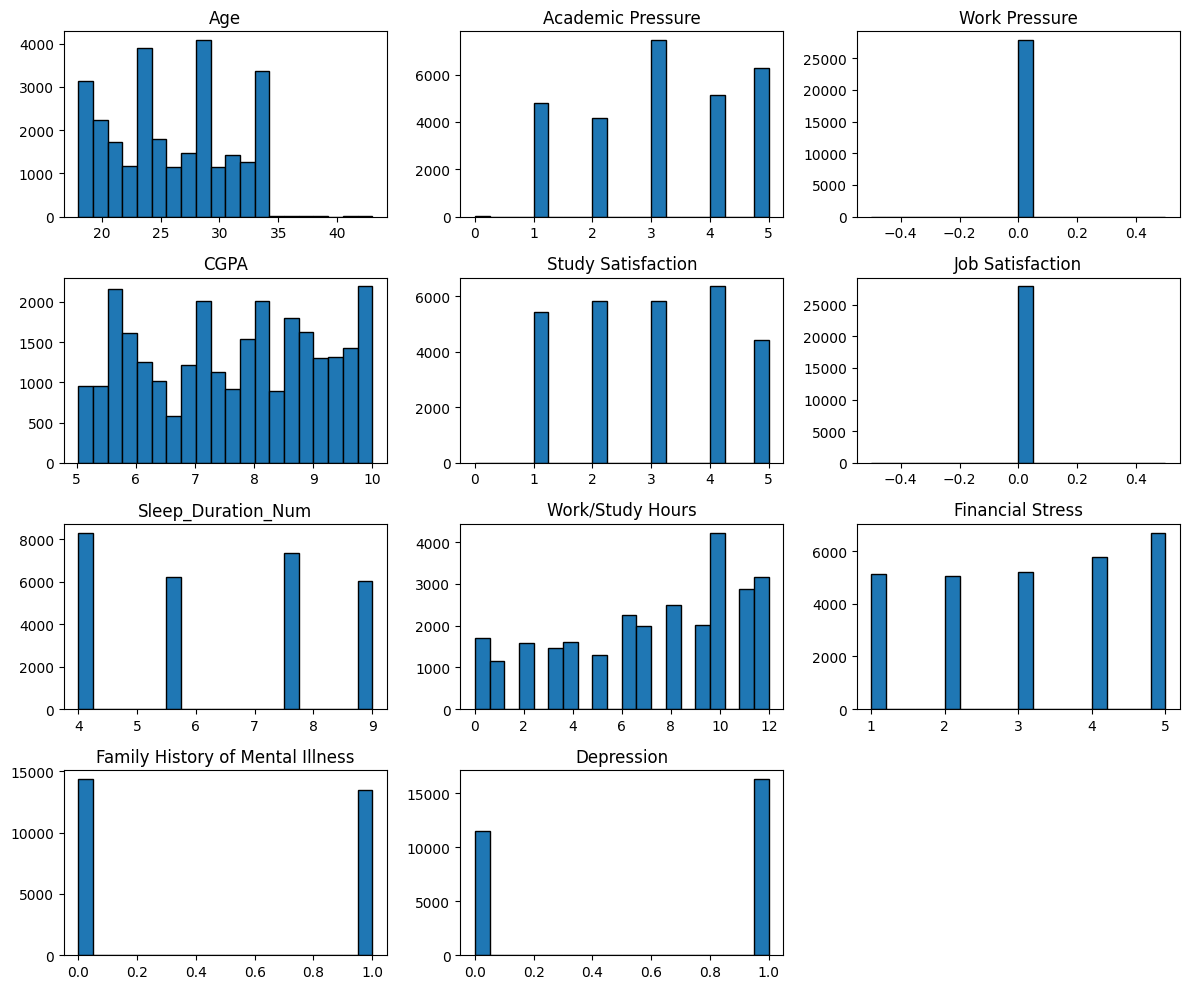

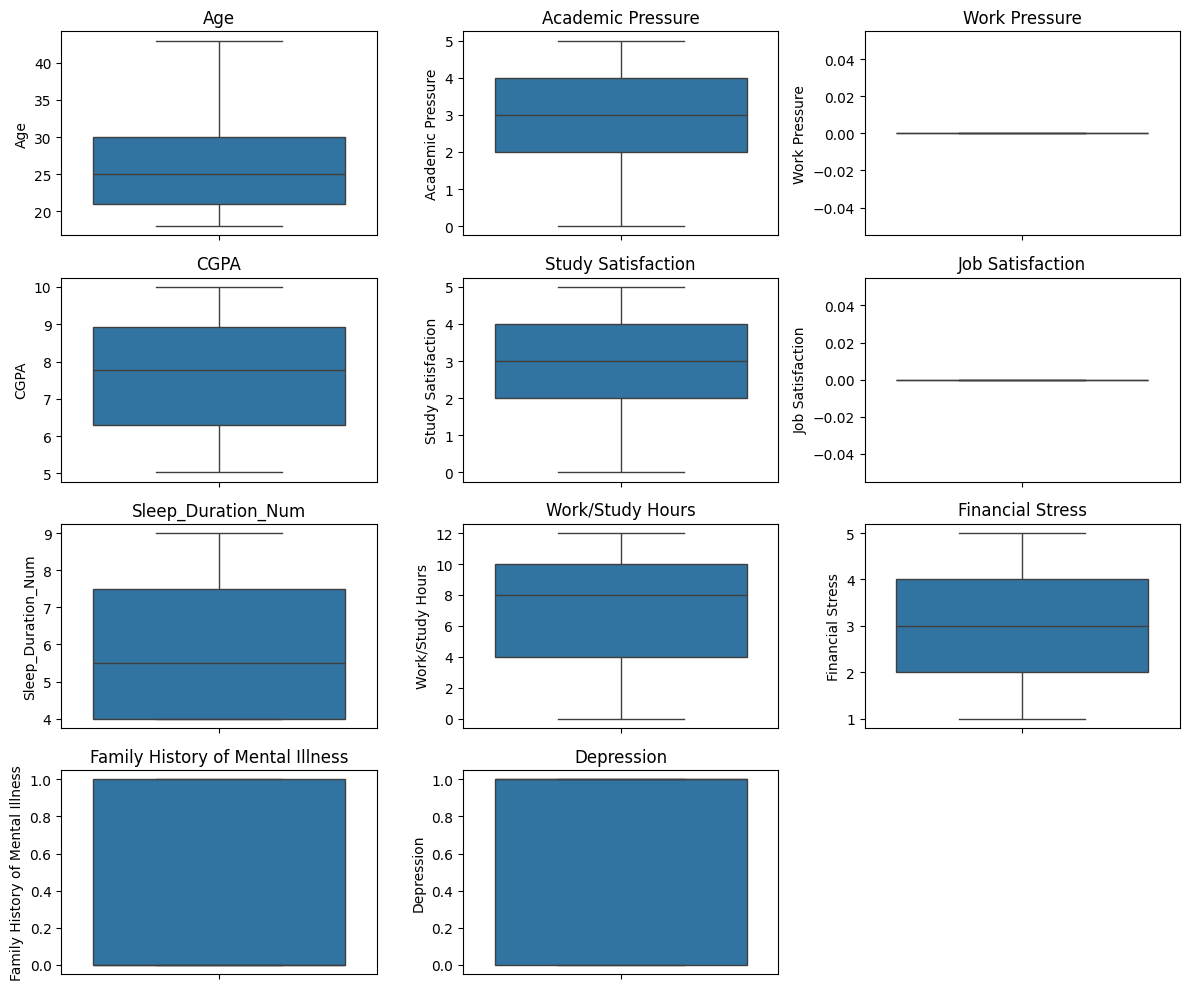

In [44]:
# 1. Check for missing values and verify data types
print("\nMissing Values per Column:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

# 2. Summary statistics for numeric features
print("\nSummary Statistics for Numeric Features:")
print(df.describe())

# 3. Distribution checks (histograms and boxplots)
numeric_columns = [
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Job Satisfaction', 'Sleep_Duration_Num',
    'Work/Study Hours', 'Financial Stress',
    'Family History of Mental Illness', 'Depression'
]

plt.figure(figsize=(12, 10))
for i, col in enumerate(numeric_columns):
    plt.subplot(4, 3, i+1)
    plt.hist(df[col].dropna(), bins=20, edgecolor='black')
    plt.title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
for i, col in enumerate(numeric_columns):
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


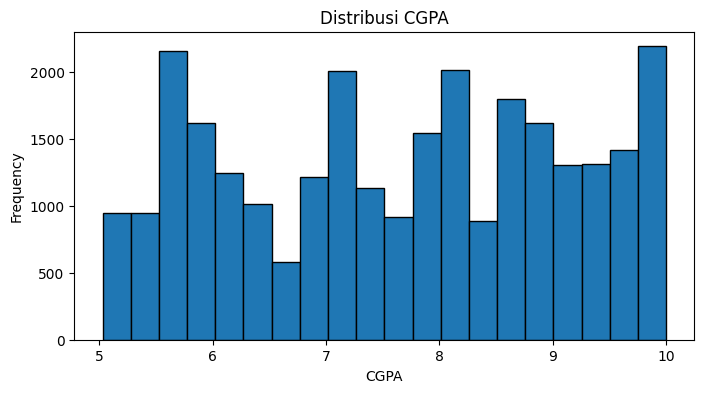

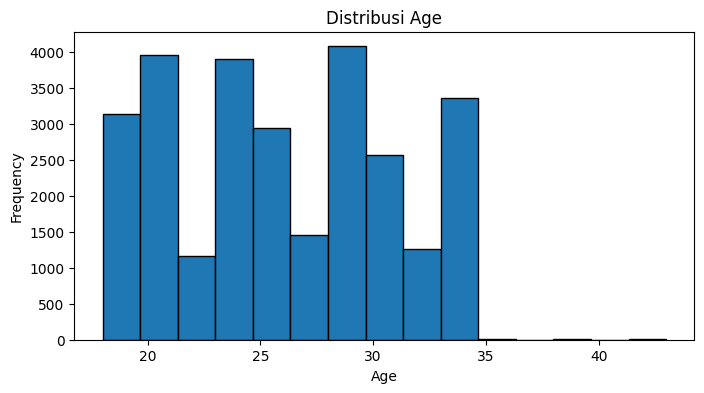

<ipython-input-45-2776946992>:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df['Academic Pressure'], df['CGPA'],cmap='viridis', s=50, alpha=0.6)


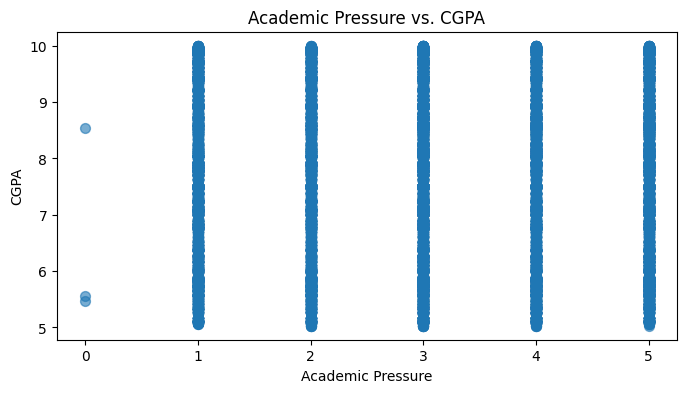

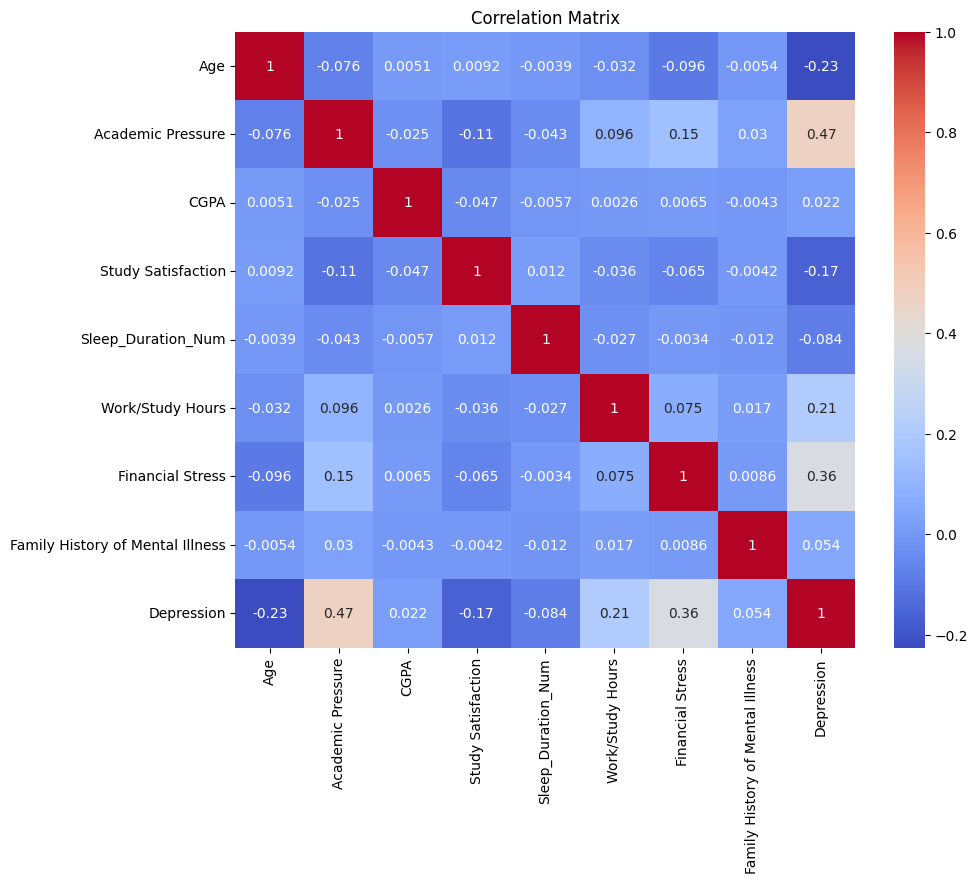

In [45]:
plt.figure(figsize=(8, 4))
plt.hist(df['CGPA'].dropna(), bins=20, edgecolor='black')
plt.xlabel('CGPA')
plt.ylabel('Frequency')
plt.title('Distribusi CGPA')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['Age'].dropna(), bins=15, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribusi Age')
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(df['Academic Pressure'], df['CGPA'],cmap='viridis', s=50, alpha=0.6)
plt.xlabel('Academic Pressure')
plt.ylabel('CGPA')
plt.title('Academic Pressure vs. CGPA')
plt.show()


numeric_features_eda = [
    'Age', 'Academic Pressure',  'CGPA',
    'Study Satisfaction',  'Sleep_Duration_Num',
    'Work/Study Hours', 'Financial Stress',
    'Family History of Mental Illness', 'Depression'
]

corr_matrix = df[numeric_features_eda].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


### Feature Engineering


In [46]:
# Buat kolom "Stress_Score" dengan menggabungkan Academic Pressure dan Work Pressure
df['Stress_Score'] = (df['Academic Pressure'] + df['Work Pressure']) / 2

# Sintesis metrik "Lifestyle_Balance" menggunakan Sleep Duration, Study Satisfaction, dan Job Satisfaction
lifestyle_features = ['Sleep_Duration_Num', 'Study Satisfaction', 'Job Satisfaction']

scaler = StandardScaler()
lifestyle_scaled = scaler.fit_transform(df[lifestyle_features])

# Buat DataFrame untuk nilai yang telah diskalakan dengan index yang sama seperti df
lifestyle_scaled_df = pd.DataFrame(
    lifestyle_scaled,
    columns=[f'{feat}_scaled' for feat in lifestyle_features],
    index=df.index
)

# Gabungkan DataFrame hasil scaling dengan DataFrame asli
df = pd.concat([df, lifestyle_scaled_df], axis=1)

# Buat metrik komposit "Lifestyle_Balance" dengan bobot yang telah disesuaikan
df['Lifestyle_Balance'] = (
    0.4 * df['Sleep_Duration_Num_scaled'] +
    0.3 * df['Study Satisfaction_scaled'] +
    0.3 * df['Job Satisfaction_scaled']
)

print(df[['Stress_Score', 'Lifestyle_Balance']].head())

   Stress_Score  Lifestyle_Balance
0           2.5          -0.383221
1           1.0           0.278334
2           1.5          -0.034647
3           1.5           0.034088
4           2.0          -0.162702


insight:
- **Stress_Score sebagai Indikator Beban Gabungan**  
  Dengan menggabungkan `Academic Pressure` dan `Work Pressure` menjadi satu metrik (`(AP + WP)/2`), kita mendapatkan representasi tunggal dari total beban pelajar. Ini memudahkan model untuk menangkap efek kumulatif tekanan akademik dan pekerjaan daripada memproses dua variabel terpisah.

- **Standarisasi Fitur Gaya Hidup**  
  Sebelum digabung, variabel `Sleep_Duration_Num`, `Study Satisfaction`, dan `Job Satisfaction` di‐scale ke distribusi mean=0 dan σ=1.  
  - Menyamakan skala antar fitur agar komposit tidak berat sebelah pada variabel yang rentangnya lebih besar.  
  - Mencegah dominasi salah satu variabel saat dijumlahkan dalam metrik akhir.

- **Metrik Komposit Lifestyle_Balance yang Terbobot**  
  Bobot 0.4 : 0.3 : 0.3 (Sleep : StudySat : JobSat) mencerminkan prioritas bahwa **kelengkapan tidur** berpengaruh paling besar terhadap keseimbangan gaya hidup, diikuti kepuasan studi dan pekerjaan.  
  - Memberi penekanan ekstra pada tidur, yang sering kali menjadi faktor krusial dalam kesejahteraan mental.  
  - Kombinasi bobot yang dapat di‐tuning di masa depan berdasarkan validasi domain expert atau performance model.

- **Manfaat untuk Interpretabilitas & Prediksi**  
  - Dua fitur baru (`Stress_Score`, `Lifestyle_Balance`) ringkas dan intuitif, memudahkan interpretasi output model.  
  - Diharapkan meningkatkan performa klasifikasi/klasterisasi karena menggantikan beberapa fitur asli dengan metrik yang lebih informatif dan terfokus.


### Clustering


In [47]:
# Pilih fitur untuk clustering (termasuk fitur sintetis)
cluster_features = ['Age', 'CGPA', 'Sleep_Duration_Num', 'Stress_Score', 'Lifestyle_Balance']

#  Lakukan clustering K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[cluster_features])

# Gunakan PCA untuk mereduksi dimensi menjadi 2 untuk visualisasi.
pca = PCA(n_components=2)
components = pca.fit_transform(df[cluster_features])
df['Component1'] = components[:, 0]
df['Component2'] = components[:, 1]


insight:
- **Pemilihan Fitur untuk Clustering**  
  Dengan memasukkan **usia (Age)**, **kinerja akademik (CGPA)**, **durasi tidur (Sleep_Duration_Num)**, **Stress_Score** (gabungan tekanan akademik & kerja), dan **Lifestyle_Balance** (gabungan kualitas tidur & kepuasan studi/kerja), clustering menitikberatkan pada kombinasi demografi, performa akademik, dan kesejahteraan mental.

- **Pembagian ke Tiga Segmen (K=3)**  
  Menggunakan K-Means dengan `n_clusters=3` membagi populasi pelajar ke dalam tiga kelompok berdasarkan kemiripan profil kelima fitur tersebut. Parameter `random_state=42` memastikan hasil yang **reproducible**.

- **Reduksi Dimensi untuk Visualisasi**  
  PCA mereduksi kelima fitur menjadi dua komponen utama (`Component1` & `Component2`), memungkinkan plot scatter 2D di mana masing-masing titik berwarna menurut label `Cluster`.  
  - **Component1** dan **Component2** memaksimalkan variansi data, sehingga cluster lebih mudah diidentifikasi secara visual.

Cluster Profiling (Mean Values):
               Age      CGPA  Sleep_Duration_Num  Stress_Score  \
Cluster                                                          
0        25.472302  7.680067            6.324372      1.592582   
1        31.506103  7.671955            6.341216      1.500763   
2        19.917120  7.616495            6.352934      1.622202   

         Lifestyle_Balance  
Cluster                     
0                -0.017070  
1                 0.010754  
2                 0.009610  

Cluster Profiling (Standard Deviations):
              Age      CGPA  Sleep_Duration_Num  Stress_Score  \
Cluster                                                         
0        1.770405  1.476047            1.922275      0.690029   
1        1.821329  1.492084            1.909139      0.687292   
2        1.311218  1.417730            1.919420      0.688164   

         Lifestyle_Balance  
Cluster                     
0                 0.498458  
1                 0.502472  
2      

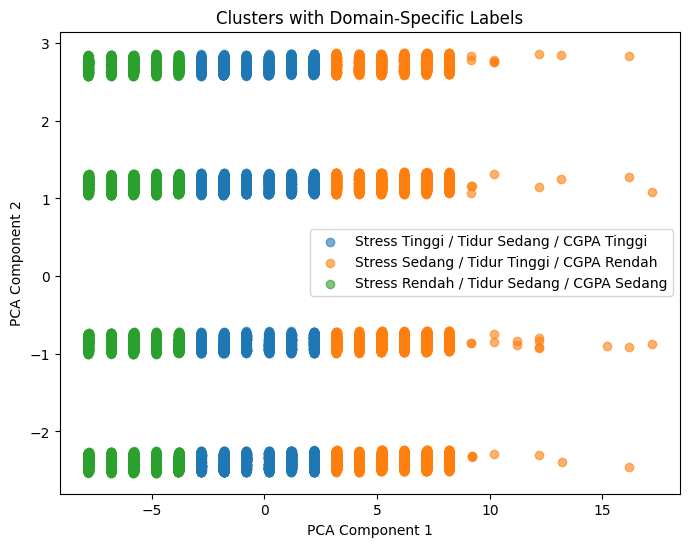

In [48]:
# =======================
# Profiling Klaster
# =======================
# Hitung statistik deskriptif untuk setiap klaster (nilai rata-rata)
cluster_profile_mean = df.groupby('Cluster')[cluster_features].mean()
print("Cluster Profiling (Mean Values):")
print(cluster_profile_mean)

# Hitung standar deviasi untuk setiap klaster
cluster_profile_std = df.groupby('Cluster')[cluster_features].std()
print("\nCluster Profiling (Standard Deviations):")
print(cluster_profile_std)

# -----------------------
# Pemberian Label klaster
# -----------------------
cluster_labels = {
    0: "Stress Tinggi / Tidur Sedang / CGPA Tinggi",
    1: "Stress Sedang / Tidur Tinggi / CGPA Rendah",
    2: "Stress Rendah / Tidur Sedang / CGPA Sedang"
}

# Map labels to a new column in DataFrame.
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

print("\nSample dengan Cluster Labels:")
print(df[['Cluster', 'Cluster_Label']].head())

# Annotate the PCA scatter plot with the domain-specific labels.
plt.figure(figsize=(8, 6))
for clus in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == clus]
    plt.scatter(cluster_data['Component1'], cluster_data['Component2'],
                label=cluster_labels.get(clus, f"Cluster {clus}"),
                alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clusters with Domain-Specific Labels')
plt.legend()
plt.show()

### Insight Hasil Clustering :


### Ringkasan Cluster

* 🔵 **Cluster 0**: Stress Tinggi / Tidur Sedang / CGPA Tinggi
* 🟠 **Cluster 1**: Stress Sedang / Tidur Tinggi / CGPA Rendah
* 🟢 **Cluster 2**: Stress Rendah / Tidur Sedang / CGPA Sedang

---

### 🔵 Cluster 0: Stress Tinggi / Tidur Sedang / CGPA Tinggi

* **Usia Rata‑Rata**: 25,5 tahun
* **CGPA**: 7,68 (tinggi)
* **Durasi Tidur**: 6,32 jam (sedang)
* **Stress Score**: 1,59 (tertinggi)
* **Lifestyle Balance**: -0,02 (sedikit negatif)

**Insight**:
Kelompok ini tergolong *high-achievers* yang mempertahankan IP (CGPA) tinggi namun membayar dengan tingkat stres yang tinggi dan keseimbangan hidup kurang baik.

**Rekomendasi Intervensi**:

1. Pelatihan manajemen stres (misalnya mindfulness, time-management)
2. Konseling work–life balance untuk mencegah burnout

---

### 🟠 Cluster 1: Stress Sedang / Tidur Tinggi / CGPA Rendah

* **Usia Rata‑Rata**: 31,5 tahun
* **CGPA**: 7,67 (rendah)
* **Durasi Tidur**: 6,34 jam (tinggi)
* **Stress Score**: 1,50 (sedang)
* **Lifestyle Balance**: 0,01 (sedikit positif)

**Insight**:
Kelompok ini memiliki tingkat stres yang moderat dan tidur lebih lama, namun capaian akademik belum optimal—mungkin tidur sebagai mekanisme koping.

**Rekomendasi Intervensi**:

1. Pelatihan keterampilan belajar (study skills, goal-setting)
2. Evaluasi kualitas tidur, bukan hanya kuantitas

---

### 🟢 Cluster 2: Stress Rendah / Tidur Sedang / CGPA Sedang

* **Usia Rata‑Rata**: 19,9 tahun
* **CGPA**: 7,62 (sedang)
* **Durasi Tidur**: 6,35 jam (sedang)
* **Stress Score**: 1,62 (terendah)
* **Lifestyle Balance**: 0,01 (positif)

**Insight**:
Kelompok ini relatif *well-balanced* dengan stres rendah, tidur dan prestasi akademik stabil. Bisa menjadi benchmark positif.

**Rekomendasi Intervensi**:

1. Program peer-support untuk mempertahankan pola positif
2. Identifikasi faktor pendorong (faktor protektif) untuk ditransfer ke cluster lain

---




### Predictive Modeling dan evaluasi

In [51]:
# Pemilihan Fitur (Predictors)
predictor_cols = [
    'Age',
    'Academic Pressure',
    'Work Pressure',
    'CGPA',
    'Study Satisfaction',
    'Job Satisfaction',
    'Sleep_Duration_Num',
    'Stress_Score',
    'Lifestyle_Balance',
    'Work/Study Hours',
    'Financial Stress',
    'Family History of Mental Illness'
]

X = df[predictor_cols]
y = df['Depression']

# Imputasi Missing Values X dengan menggunakan median.
X = X.fillna(X.median())

# Split dataset jadi training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



insight:
- **Pemilihan Fitur (Predictors)**  
  Menggabungkan 12 variabel, baik yang asli (usia, tekanan akademik/kerja, CGPA, kepuasan, jam kerja/belajar, stres finansial, riwayat keluarga) maupun dua fitur sintetis (`Stress_Score` dan `Lifestyle_Balance`). Ini memastikan model dapat menangkap aspek demografis, akademik, gaya hidup, dan tekanan mental dalam satu framework.

- **Imputasi Missing Values**  
  Mengisi nilai yang tersisa dengan **median** tiap kolom (`X.fillna(X.median())`) menjaga distribusi sentral tanpa terpengaruh outlier ekstrem, sehingga dataset siap untuk pelatihan tanpa baris kosong.

- **Pemisahan Data (Train/Test Split)**  
  Mengalokasikan **80% data** untuk pelatihan dan **20%** untuk pengujian, dengan `random_state=42` untuk reproduktibilitas.  
  - Pastikan proporsi kelas `Depression` (0 vs 1) tetap seimbang di kedua set—jika tidak, pertimbangkan `stratify=y` agar evaluasi lebih adil.

##### membangun model prediksi Naive Bayes, Decision Tree , SVM

In [52]:
# 1. Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== Naive Bayes ===")
print("Naive Bayes Model Akurasi:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
print("\n")

# 2. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree ===")
print("Decision Tree Model Akurasi:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("\n")

# 3. Support Vector Machine (SVM)
svm_model = SVC(kernel='linear', random_state=42)  # kernel linear untuk klasifikasi biner sederhana
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("=== Support Vector Machine (SVM) ===")
print("Support Vector Machine Akurasi:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("\n")


=== Naive Bayes ===
Naive Bayes Model Akurasi: 0.7840358744394619
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      2324
           1       0.81      0.82      0.82      3251

    accuracy                           0.78      5575
   macro avg       0.78      0.78      0.78      5575
weighted avg       0.78      0.78      0.78      5575



=== Decision Tree ===
Decision Tree Model Akurasi: 0.7038565022421525
              precision    recall  f1-score   support

           0       0.64      0.66      0.65      2324
           1       0.75      0.74      0.74      3251

    accuracy                           0.70      5575
   macro avg       0.70      0.70      0.70      5575
weighted avg       0.70      0.70      0.70      5575



=== Support Vector Machine (SVM) ===
Support Vector Machine Akurasi: 0.8
              precision    recall  f1-score   support

           0       0.78      0.72      0.75      2324
           1       0.81 

# Hasil Evaluasi Model

Berdasarkan hasil pengujian pada data uji:

## 1. Support Vector Machine (SVM) — Model Terbaik
- **Akurasi**: 80,0%  
- **Precision** (kelas 0/1): 0,78 / 0,81  
- **Recall** (kelas 0/1): 0,72 / 0,86  
- **F1-score** (kelas 0/1): 0,75 / 0,83  
- **Kelebihan**:  
  - Recall tinggi pada kelas depresi (0,86) → meminimalkan kasus terlewat  
  - Keseimbangan metrik keseluruhan terbaik  

## 2. Naive Bayes — Model Kedua
- **Akurasi**: 78,4%  
- **Precision** (kelas 0/1): 0,75 / 0,81  
- **Recall** (kelas 0/1): 0,73 / 0,82  
- **F1-score** (kelas 0/1): 0,74 / 0,82  
- **Kelebihan**:  
  - Performa mendekati SVM  
  - Training sangat cepat, cocok untuk skenario dengan resource terbatas  

## 3. Decision Tree — Model Terlemah
- **Akurasi**: 70,4%  
- **Precision** (kelas 0/1): 0,64 / 0,75  
- **Recall** (kelas 0/1): 0,66 / 0,74  
- **F1-score** (kelas 0/1): 0,65 / 0,74  
- **Kelemahan**:  
  - Cenderung underfit/overfit tanpa tuning  
  - Kinerja jauh di bawah dua model lainnya  

## Rekomendasi
1. **Gunakan SVM** sebagai model utama untuk deteksi risiko depresi.  
2. Simpan **Naive Bayes** sebagai opsi cepat untuk inferensi real-time.  
3. **Optimasi Decision Tree** (pruning, `max_depth`, `min_samples_leaf`) atau pertimbangkan ensemble (Random Forest, Boosting) untuk meningkatkan akurasi.